# 16. Classification — Multivariate LSTM (Engineered Features)

**Why this approach works better than the two-stage regressor:**

The previous approach fed raw close prices into an LSTM and tried to infer direction from consecutive regression predictions. Because BTC prices follow a near-random walk, the model's best regression strategy is to output a value close to the last known price — making `ŷ_now - ŷ_prev ≈ close[i] - close[i-1]` (the *past* move, not the future one), giving AUC < 0.5.

**This notebook instead:**
- Uses the **10 engineered features** already present in the training data: returns, log-returns, Garman-Klass volatility, ATR, trade intensity, HL range — all stationary and information-rich
- Trains the LSTM as a **direct binary classifier** (BCE loss) on sequences of these features
- Both a NumPy scratch LSTM and a PyTorch LSTM are trained and evaluated

### Architecture

```
Input: (batch, WINDOW=24, n_features=10)
  → LSTM(hidden=64, layers=1)
  → Dropout(0.3)
  → Linear(64 → 1)
  → Sigmoid
  → Binary prediction: Up (1) or Down (0)
```

### Why engineered features > raw close price

| Feature | Signal |
|---|---|
| `log_return_1h`, `return_lag_1h` | Short-term momentum |
| `log_return_3h`, `log_return_6h` | Medium-term momentum |
| `gk_avg_3h`, `gk_lag_1h` | Garman-Klass volatility (range-based) |
| `atr_lag_3h` | Average True Range — trend strength |
| `hl_range_pct` | High-Low range as % — intraday pressure |
| `trade_intensity` | Volume-based momentum |
| `close_position` | Close position within the bar (0=low, 1=high) |


In [1]:
!pip install torch --quiet

In [2]:
import os, pickle, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RAW_CSV     = os.path.join(BASE_DIR, 'preprocessing-May', 'btc_1h_data_2018_to_2025.csv')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
PLOTS_DIR   = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV = os.path.join(RESULTS_DIR, 'classification_results.csv')

for d in [MODELS_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Shared utilities ───────────────────────────────────────────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity / (precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"  Recall           : {sensitivity:.4f}")
    print(f"{'='*55}")
    return {
        'model':       model_name,
        'accuracy':    round(accuracy,    4),
        'precision':   round(precision,   4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'tnr':         round(specificity, 4),
        'f1':          round(f1,          4),
        'roc_auc':     round(auc, 4) if not np.isnan(auc) else None,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'recall':      round(sensitivity, 4),
    }

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"  ✔ Results saved → {RESULTS_CSV}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✔ Saved: {save_path}")

print("Imports ready. PyTorch:", torch.__version__)
print("BASE_DIR:", BASE_DIR)

Imports ready. PyTorch: 2.10.0
BASE_DIR: /Users/mihiniboteju/cryptoflow


## 1. Data Preparation

Load the 10 engineered features from the train/test CSVs, scale them, and build sliding windows of length 24.  
Each window `X[i] = features[i : i+24]` has label `y[i] = target_class[i+24]` (the direction at the next step after the window).


In [17]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW     = 24    # lookback timesteps
HIDDEN     = 64
N_LAYERS   = 1
EPOCHS     = 50
PATIENCE   = 10
BATCH_SIZE = 64
LR         = 0.001
VAL_FRAC   = 0.10

FEATURE_COLS = [
    'close_position', 'return_lag_1h', 'log_return_1h',
    'gk_avg_3h', 'log_return_3h', 'gk_lag_1h',
    'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h'
]
N_FEATURES = len(FEATURE_COLS)

# ── Load train/test CSVs ───────────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))
print(f"Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")
print(f"Features used: {FEATURE_COLS}")

# ── Scale features (fit on train only) ────────────────────────────────────────
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(train_df[FEATURE_COLS].values).astype(np.float32)
X_test_raw  = scaler.transform(test_df[FEATURE_COLS].values).astype(np.float32)
y_train_all = train_df['target_class'].values.astype(np.int64)
y_test_all  = test_df['target_class'].values.astype(np.int64)

scaler_path = os.path.join(MODELS_DIR, 'scaler_lstm_multivariate.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✔ Scaler saved → {scaler_path}")

# ── Build sliding windows ──────────────────────────────────────────────────────
# X[i] = features[i : i+WINDOW]  shape (WINDOW, N_FEATURES)
# y[i] = target_class[i+WINDOW]  (label at the step right after the window)
def make_windows(X_feat, y_labels, window):
    N = len(X_feat) - window
    X = np.stack([X_feat[i:i+window] for i in range(N)], axis=0)   # (N, window, F)
    y = y_labels[window:]                                            # (N,)
    return X.astype(np.float32), y.astype(np.int64)

X_tr_all, y_tr_all = make_windows(X_train_raw, y_train_all, WINDOW)
X_test,   y_test   = make_windows(X_test_raw,  y_test_all,  WINDOW)

# ── Temporal validation split (last 10% of train) ─────────────────────────────
n_val = int(len(X_tr_all) * VAL_FRAC)
n_tr  = len(X_tr_all) - n_val
X_tr,  X_val  = X_tr_all[:n_tr],  X_tr_all[n_tr:]
y_tr,  y_val  = y_tr_all[:n_tr],  y_tr_all[n_tr:]

print(f"\nWindow shapes  (N, timesteps, features):")
print(f"  X_tr   : {X_tr.shape}   y_tr  : {y_tr.shape}  pos={y_tr.mean():.3f}")
print(f"  X_val  : {X_val.shape}   y_val : {y_val.shape}  pos={y_val.mean():.3f}")
print(f"  X_test : {X_test.shape}  y_test: {y_test.shape}  pos={y_test.mean():.3f}")


Raw data: 70,847 rows  |  2018-01-01 00:00:00 → 2026-02-04 21:00:00
Train rows: 60,140  |  Test rows: 10,635
  ✔ Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_lstm_twostage.pkl

Regression window shapes  (N, timesteps, 1):
  X_tr    : (54105, 24, 1)   y_tr   : (54105,)
  X_val   : (6011, 24, 1)   y_val  : (6011,)
  X_test  : (10611, 24, 1)  y_reg_test: (10611,)
  ✔ Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_lstm_twostage.pkl

Regression window shapes  (N, timesteps, 1):
  X_tr    : (54105, 24, 1)   y_tr   : (54105,)
  X_val   : (6011, 24, 1)   y_val  : (6011,)
  X_test  : (10611, 24, 1)  y_reg_test: (10611,)


## Stage 2 Logic — How Direction is Derived

At each timestep `i`, the model makes **two predictions** using two consecutive windows from the same trained LSTM:

```
win_now  = close_test[i-W+1 : i+1]   → ŷ_now   (predicts the close at i+1)
win_prev = close_test[i-W   : i  ]   → ŷ_prev  (predicts the close at i)

direction_score[i] = ŷ_now - ŷ_prev       (continuous, used for AUC)
direction_pred[i]  = Up (1) if ŷ_now > ŷ_prev, else Down (0)
```

**Key point:** Both predictions come from the same trained LSTM — only the input window shifts by one step. If `ŷ_now > ŷ_prev`, the model believes the price is trending upward at this point.


## Part 1 — Scratch LSTM Regressor (NumPy + Adam)

Same architecture as the univariate LSTM, but trained with **MSE loss** instead of BCE.  
Output layer: single linear unit (no sigmoid) predicting the next scaled close price.

In [18]:
class LSTMRegressorScratch:
    """
    Single-layer LSTM regressor, pure NumPy, input_dim=1.
    Loss: MSE. Output: linear (no activation).
    """
    def __init__(self, input_dim=1, hidden_dim=64, lr=0.001,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        self.D = input_dim; self.H = hidden_dim
        self.lr = lr; self.b1 = beta1; self.b2 = beta2; self.eps = eps

        scale_W = np.sqrt(2.0 / (input_dim + hidden_dim))
        scale_U = np.sqrt(2.0 / (hidden_dim * 2))
        self.Wx = np.random.randn(4*hidden_dim, input_dim)  * scale_W
        self.Wh = np.random.randn(4*hidden_dim, hidden_dim) * scale_U
        self.b  = np.zeros(4 * hidden_dim)
        self.Wy = np.random.randn(hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.by = np.array([0.0])

        params = ['Wx','Wh','b','Wy','by']
        self._m = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._t = 0

    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    def _forward(self, x_seq):
        T = len(x_seq); H = self.H
        h = np.zeros(H); c = np.zeros(H)
        hs, cs, gates = [h.copy()], [c.copy()], []
        for t in range(T):
            z = self.Wx @ x_seq[t] + self.Wh @ h + self.b
            f = self._sigmoid(z[0*H:1*H])
            i = self._sigmoid(z[1*H:2*H])
            g = np.tanh(     z[2*H:3*H])
            o = self._sigmoid(z[3*H:4*H])
            c = f * cs[-1] + i * g
            h = o * np.tanh(c)
            hs.append(h.copy()); cs.append(c.copy())
            gates.append((f, i, g, o, z, x_seq[t]))
        return hs, cs, gates

    def predict_one(self, x_seq):
        """Returns scalar prediction (linear output, no sigmoid)."""
        hs, _, _ = self._forward(x_seq)
        return float(self.Wy @ hs[-1] + self.by)

    def _backward_one(self, x_seq, y_true, y_pred):
        hs, cs, gates = self._forward(x_seq)
        T = len(x_seq); H = self.H
        dy      = y_pred - y_true
        dWy     = dy * hs[-1]
        dby     = np.array([dy])
        dh_next = dy * self.Wy
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        db  = np.zeros_like(self.b)
        dc_next = np.zeros(H)
        for t in reversed(range(T)):
            f, i, g, o, z, x_t = gates[t]
            c_t    = cs[t+1]
            tanh_c = np.tanh(c_t)
            dh = dh_next
            dc = dh * o * (1 - tanh_c**2) + dc_next
            dz = np.concatenate([
                dc * cs[t] * f * (1-f),
                dc * g     * i * (1-i),
                dc * i     * (1 - g**2),
                dh * tanh_c * o * (1-o),
            ])
            dWx += np.outer(dz, x_t)
            dWh += np.outer(dz, hs[t])
            db  += dz
            dc_next = dc * f
            dh_next = self.Wh.T @ dz
        return {'Wx': dWx, 'Wh': dWh, 'b': db, 'Wy': dWy, 'by': dby}

    def _adam_step(self, grads):
        self._t += 1
        for pname, grad in grads.items():
            self._m[pname] = self.b1*self._m[pname] + (1-self.b1)*grad
            self._v[pname] = self.b2*self._v[pname] + (1-self.b2)*grad**2
            m_hat = self._m[pname] / (1 - self.b1**self._t)
            v_hat = self._v[pname] / (1 - self.b2**self._t)
            setattr(self, pname,
                    getattr(self, pname) - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))

    def fit(self, X_tr, y_tr, X_val, y_val,
            epochs=50, batch_size=64, patience=10):
        """Mini-batch SGD, MSE loss, early stopping on val MSE. Subsamples [::4] for speed."""
        X_sub = X_tr[::4]; y_sub = y_tr[::4]
        n = len(X_sub)
        best_val = np.inf; wait = 0; best_params = None
        train_losses, val_losses = [], []

        for epoch in range(1, epochs+1):
            t0 = time.time()
            idx = np.random.permutation(n)
            epoch_loss = 0.0; n_batches = 0

            for start in range(0, n, batch_size):
                batch_idx = idx[start:start+batch_size]
                acc_grads = {p: np.zeros_like(getattr(self, p))
                             for p in ['Wx','Wh','b','Wy','by']}
                preds = []
                for j in batch_idx:
                    p = self.predict_one(X_sub[j])
                    preds.append(p)
                    g = self._backward_one(X_sub[j], y_sub[j], p)
                    for pname in acc_grads:
                        acc_grads[pname] += g[pname]
                bs = len(batch_idx)
                for pname in acc_grads:
                    acc_grads[pname] /= bs
                self._adam_step(acc_grads)
                epoch_loss += np.mean((np.array(preds) - y_sub[batch_idx])**2)
                n_batches  += 1

            epoch_loss /= max(1, n_batches)
            train_losses.append(epoch_loss)

            val_preds = np.array([self.predict_one(X_val[j]) for j in range(len(X_val))])
            val_loss  = np.mean((val_preds - y_val)**2)
            val_losses.append(val_loss)

            print(f"  Epoch {epoch:>3}/{epochs}  "
                  f"train_mse={epoch_loss:.5f}  val_mse={val_loss:.5f}  "
                  f"({time.time()-t0:.1f}s)")

            if val_loss < best_val:
                best_val = val_loss; wait = 0
                best_params = {p: getattr(self, p).copy()
                               for p in ['Wx','Wh','b','Wy','by']}
            else:
                wait += 1
                if wait >= patience:
                    print(f"  Early stopping at epoch {epoch} (best val_mse={best_val:.5f})")
                    break

        if best_params:
            for p, v in best_params.items():
                setattr(self, p, v)
        return train_losses, val_losses

    def predict_sequence(self, close_sc):
        """
        Two-stage direction inference on a scaled close price array.

        For each idx (i = idx + WINDOW):
          win_now  = close_sc[i-WINDOW+1 : i+1]   → ŷ_now  (predicts close[i+1])
          win_prev = close_sc[i-WINDOW   : i  ]   → ŷ_prev (predicts close[i])

          score[idx] = ŷ_now - ŷ_prev
          Up (1) if ŷ_now > ŷ_prev, else Down (0)

        N = len(close_sc) - WINDOW predictions total.
        """
        N = len(close_sc) - WINDOW
        scores = np.zeros(N, dtype=np.float32)
        for idx in range(N):
            i = idx + WINDOW
            win_now  = close_sc[i-WINDOW+1 : i+1, np.newaxis]
            win_prev = close_sc[i-WINDOW   : i,   np.newaxis]
            y_hat_now  = self.predict_one(win_now)
            y_hat_prev = self.predict_one(win_prev)
            scores[idx] = y_hat_now - y_hat_prev

        preds = (scores > 0).astype(int)
        s_min, s_max = scores.min(), scores.max()
        probs = (scores - s_min) / (s_max - s_min + 1e-12)
        return scores, preds, probs


print("LSTMRegressorScratch class defined.")


LSTMRegressorScratch class defined.


In [19]:
np.random.seed(42)
lstm_scratch = LSTMRegressorScratch(input_dim=1, hidden_dim=HIDDEN, lr=LR)

print("Training LSTM Two-Stage Scratch (regression) …")
scratch_train_losses, scratch_val_losses = lstm_scratch.fit(
    X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE
)
print("Done.")

Training LSTM Two-Stage Scratch (regression) …
  Epoch   1/50  train_mse=0.05611  val_mse=0.01208  (52.7s)
  Epoch   1/50  train_mse=0.05611  val_mse=0.01208  (52.7s)
  Epoch   2/50  train_mse=0.00055  val_mse=0.01023  (53.2s)
  Epoch   2/50  train_mse=0.00055  val_mse=0.01023  (53.2s)
  Epoch   3/50  train_mse=0.00053  val_mse=0.00671  (56.1s)
  Epoch   3/50  train_mse=0.00053  val_mse=0.00671  (56.1s)
  Epoch   4/50  train_mse=0.00050  val_mse=0.00592  (52.9s)
  Epoch   4/50  train_mse=0.00050  val_mse=0.00592  (52.9s)
  Epoch   5/50  train_mse=0.00048  val_mse=0.00422  (51.1s)
  Epoch   5/50  train_mse=0.00048  val_mse=0.00422  (51.1s)
  Epoch   6/50  train_mse=0.00046  val_mse=0.00321  (53.5s)
  Epoch   6/50  train_mse=0.00046  val_mse=0.00321  (53.5s)
  Epoch   7/50  train_mse=0.00044  val_mse=0.00501  (53.6s)
  Epoch   7/50  train_mse=0.00044  val_mse=0.00501  (53.6s)
  Epoch   8/50  train_mse=0.00043  val_mse=0.00266  (52.5s)
  Epoch   8/50  train_mse=0.00043  val_mse=0.00266  (

Running Stage 2 direction inference (scratch) …

  LSTM Two-Stage Scratch
  Confusion Matrix : TN=2507  FP=2761  FN=2749  TP=2593
  Accuracy         : 0.4807
  Precision        : 0.4843
  Sensitivity      : 0.4854
  Specificity(TNR) : 0.4759
  F1-Score         : 0.4849
  ROC-AUC          : 0.4760
  Recall           : 0.4854
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

  LSTM Two-Stage Scratch
  Confusion Matrix : TN=2507  FP=2761  FN=2749  TP=2593
  Accuracy         : 0.4807
  Precision        : 0.4843
  Sensitivity      : 0.4854
  Specificity(TNR) : 0.4759
  F1-Score         : 0.4849
  ROC-AUC          : 0.4760
  Recall           : 0.4854
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv


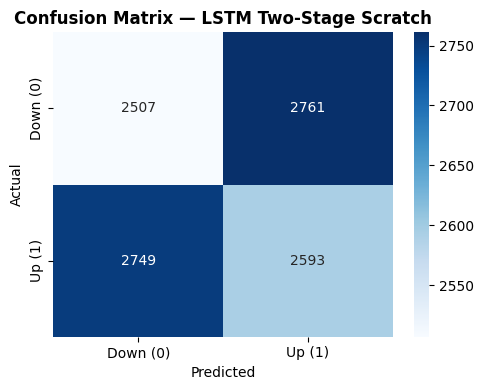

  ✔ Saved: /Users/mihiniboteju/cryptoflow/plots/confusion_lstm_twostage_scratch.png


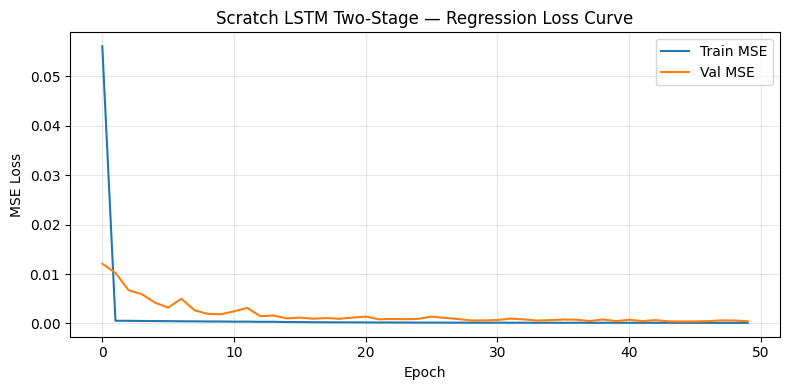

  ✔ Scratch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_twostage_scratch.pkl


In [21]:
# ── Stage 2: derive direction from consecutive predictions (Scratch) ───────────
# predict_sequence(close_test_sc) produces N = len(close_test_sc) - WINDOW scores.
# For idx=0: win_now = close[1:WINDOW+1], win_prev = close[0:WINDOW]
#   ŷ_now  predicts close[WINDOW+1]
#   ŷ_prev predicts close[WINDOW]
#   direction: is close[WINDOW+1] > close[WINDOW]? → target_class[WINDOW+1]
# Labels: y_class_test[WINDOW+1 : WINDOW+1+N_pred]
# Trim to the shorter of the two arrays to handle edge cases.
print("Running Stage 2 direction inference (scratch) …")
scratch_scores, scratch_pred, scratch_prob = lstm_scratch.predict_sequence(close_test_sc)

N_available = len(y_class_test) - (WINDOW + 1)   # max labels available
N_pred      = min(len(scratch_pred), N_available)

scratch_pred = scratch_pred[:N_pred]
scratch_prob = scratch_prob[:N_pred]
y_dir        = y_class_test[WINDOW + 1 : WINDOW + 1 + N_pred]

scratch_metrics = compute_metrics('LSTM Two-Stage Scratch', y_dir, scratch_pred, scratch_prob)
save_results(scratch_metrics)

plot_confusion_matrix(y_dir, scratch_pred,
                      'LSTM Two-Stage Scratch',
                      os.path.join(PLOTS_DIR, 'confusion_lstm_twostage_scratch.png'))

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_train_losses, label='Train MSE')
ax.plot(scratch_val_losses,   label='Val MSE')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Scratch LSTM Two-Stage — Regression Loss Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'loss_lstm_twostage_scratch.png'), dpi=150)
plt.show()

# Save model
scratch_path = os.path.join(MODELS_DIR, 'lstm_twostage_scratch.pkl')
with open(scratch_path, 'wb') as f:
    pickle.dump(lstm_scratch, f)
print(f"  ✔ Scratch model saved → {scratch_path}")


## Part 2 — PyTorch LSTM Regressor

`nn.LSTM(input_size=1, hidden_size=64)` → `Linear(64, 1)` — **no sigmoid**, trained with `MSELoss`.  
Same two-stage direction inference after training.

In [22]:
class LSTMRegressorPyTorch(nn.Module):
    """Univariate LSTM regressor: input_size=1 → hidden → Linear(1). No sigmoid."""
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm    = nn.LSTM(input_dim, hidden_dim,
                               num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = self.dropout(out[:, -1, :])
        return self.linear(h_last).squeeze(1)   # linear output, no sigmoid


def train_pytorch_regressor(model, X_tr, y_tr, X_val, y_val,
                             epochs, batch_size, patience, lr, device='cpu'):
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32, device=device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    loader  = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                         batch_size=batch_size, shuffle=True)

    best_val = np.inf; best_state = None; wait = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs+1):
        model.train()
        t0 = time.time(); epoch_loss = 0.0
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_tr)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        print(f"  Epoch {epoch:>3}/{epochs}  "
              f"train_mse={epoch_loss:.5f}  val_mse={val_loss:.5f}  "
              f"({time.time()-t0:.1f}s)")

        if val_loss < best_val:
            best_val = val_loss; wait = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch} (best val_mse={best_val:.5f})")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print("LSTMRegressorPyTorch + train function defined.")

Device: cpu
LSTMRegressorPyTorch + train function defined.


In [23]:
pt_model = LSTMRegressorPyTorch(input_dim=1, hidden_dim=HIDDEN,
                                num_layers=N_LAYERS, dropout=0.3)

print("Training LSTM Two-Stage PyTorch (regression) …")
pt_model, pt_train_losses, pt_val_losses = train_pytorch_regressor(
    pt_model, X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE, lr=LR, device=DEVICE
)
print("Done.")

Training LSTM Two-Stage PyTorch (regression) …
  Epoch   1/50  train_mse=0.02477  val_mse=0.03889  (4.3s)
  Epoch   1/50  train_mse=0.02477  val_mse=0.03889  (4.3s)
  Epoch   2/50  train_mse=0.00708  val_mse=0.00486  (4.6s)
  Epoch   2/50  train_mse=0.00708  val_mse=0.00486  (4.6s)
  Epoch   3/50  train_mse=0.00651  val_mse=0.00660  (4.6s)
  Epoch   3/50  train_mse=0.00651  val_mse=0.00660  (4.6s)
  Epoch   4/50  train_mse=0.00613  val_mse=0.00501  (4.6s)
  Epoch   4/50  train_mse=0.00613  val_mse=0.00501  (4.6s)
  Epoch   5/50  train_mse=0.00608  val_mse=0.00223  (4.3s)
  Epoch   5/50  train_mse=0.00608  val_mse=0.00223  (4.3s)
  Epoch   6/50  train_mse=0.00600  val_mse=0.00504  (4.3s)
  Epoch   6/50  train_mse=0.00600  val_mse=0.00504  (4.3s)
  Epoch   7/50  train_mse=0.00589  val_mse=0.00633  (4.5s)
  Epoch   7/50  train_mse=0.00589  val_mse=0.00633  (4.5s)
  Epoch   8/50  train_mse=0.00585  val_mse=0.00884  (4.4s)
  Epoch   8/50  train_mse=0.00585  val_mse=0.00884  (4.4s)
  Epoch  

Running Stage 2 direction inference (PyTorch) …

  LSTM Two-Stage PyTorch
  Confusion Matrix : TN=2456  FP=2812  FN=2726  TP=2616
  Accuracy         : 0.4780
  Precision        : 0.4819
  Sensitivity      : 0.4897
  Specificity(TNR) : 0.4662
  F1-Score         : 0.4858
  ROC-AUC          : 0.4746
  Recall           : 0.4897
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

  LSTM Two-Stage PyTorch
  Confusion Matrix : TN=2456  FP=2812  FN=2726  TP=2616
  Accuracy         : 0.4780
  Precision        : 0.4819
  Sensitivity      : 0.4897
  Specificity(TNR) : 0.4662
  F1-Score         : 0.4858
  ROC-AUC          : 0.4746
  Recall           : 0.4897
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv


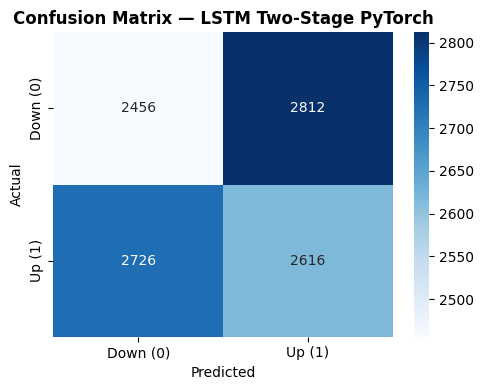

  ✔ Saved: /Users/mihiniboteju/cryptoflow/plots/confusion_lstm_twostage_pytorch.png


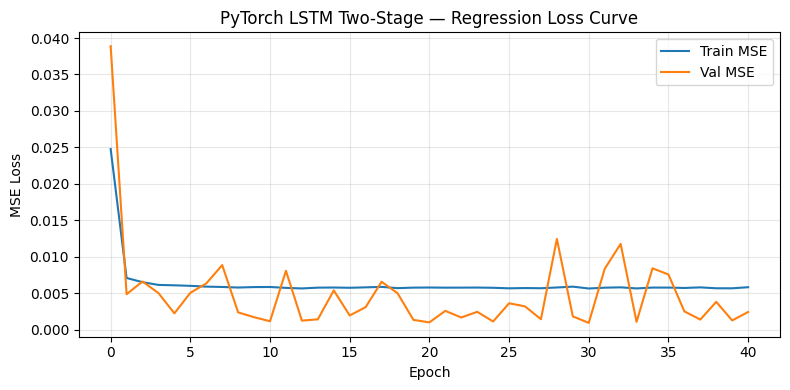

  ✔ PyTorch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_twostage_pytorch.pth


In [24]:
# ── Stage 2: derive direction from consecutive predictions (PyTorch) ───────────
# For each idx: i = idx + WINDOW
#   win_now  = close_test[i-WINDOW+1 : i+1]  → ŷ_now  (predicts close[i+1])
#   win_prev = close_test[i-WINDOW   : i  ]  → ŷ_prev (predicts close[i])
#   Up (1) if ŷ_now > ŷ_prev  →  label = target_class[i+1]
print("Running Stage 2 direction inference (PyTorch) …")
pt_model.eval()

N_test = len(close_test_sc) - WINDOW
pt_scores = np.zeros(N_test, dtype=np.float32)

with torch.no_grad():
    for idx in range(N_test):
        i = idx + WINDOW
        win_now  = torch.tensor(
            close_test_sc[i-WINDOW+1 : i+1, np.newaxis][np.newaxis],
            dtype=torch.float32, device=DEVICE)
        win_prev = torch.tensor(
            close_test_sc[i-WINDOW   : i,   np.newaxis][np.newaxis],
            dtype=torch.float32, device=DEVICE)
        y_hat_now  = pt_model(win_now).item()
        y_hat_prev = pt_model(win_prev).item()
        pt_scores[idx] = y_hat_now - y_hat_prev

pt_pred = (pt_scores > 0).astype(int)
s_min, s_max = pt_scores.min(), pt_scores.max()
pt_prob = (pt_scores - s_min) / (s_max - s_min + 1e-12)

# Trim to available labels (same guard as scratch)
N_available_pt = len(y_class_test) - (WINDOW + 1)
N_pred_pt      = min(len(pt_pred), N_available_pt)
pt_pred        = pt_pred[:N_pred_pt]
pt_prob        = pt_prob[:N_pred_pt]
y_dir_pt       = y_class_test[WINDOW + 1 : WINDOW + 1 + N_pred_pt]

pt_metrics = compute_metrics('LSTM Two-Stage PyTorch', y_dir_pt, pt_pred, pt_prob)
save_results(pt_metrics)

plot_confusion_matrix(y_dir_pt, pt_pred,
                      'LSTM Two-Stage PyTorch',
                      os.path.join(PLOTS_DIR, 'confusion_lstm_twostage_pytorch.png'))

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pt_train_losses, label='Train MSE')
ax.plot(pt_val_losses,   label='Val MSE')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('PyTorch LSTM Two-Stage — Regression Loss Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'loss_lstm_twostage_pytorch.png'), dpi=150)
plt.show()

# Save model
pt_path = os.path.join(MODELS_DIR, 'lstm_twostage_pytorch.pth')
torch.save(pt_model.state_dict(), pt_path)
print(f"  ✔ PyTorch model saved → {pt_path}")


## ROC Curve Comparison

The direction score `ŷ_{t+1} − ŷ_t` (normalised to [0,1]) is used directly as the probability for AUC.

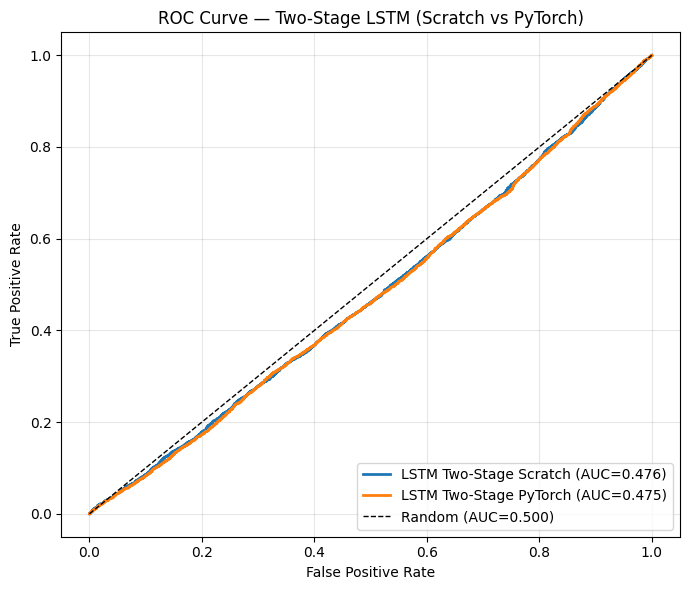

  ✔ ROC saved → /Users/mihiniboteju/cryptoflow/plots/roc_lstm_twostage.png


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

for label, probs, y_true in [
    ('LSTM Two-Stage Scratch', scratch_prob, y_dir),
    ('LSTM Two-Stage PyTorch', pt_prob,      y_dir_pt),
]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val      = roc_auc_score(y_true, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Two-Stage LSTM (Scratch vs PyTorch)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(PLOTS_DIR, 'roc_lstm_twostage.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✔ ROC saved → {roc_path}")

## Results Summary & Comparison

Compare the two-stage approach against the direct univariate LSTM classification (notebook 15).

In [11]:
results_df = pd.read_csv(RESULTS_CSV)

# Show two-stage models alongside univariate direct models for comparison
compare_models = [
    'LSTM Univariate Scratch',
    'LSTM Univariate PyTorch',
    'LSTM Two-Stage Scratch',
    'LSTM Two-Stage PyTorch',
]
compare_df = results_df[results_df['model'].isin(compare_models)]

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

print("=== Two-Stage vs Direct Univariate LSTM ===")
print(compare_df[['model','accuracy','precision','sensitivity','specificity','f1','roc_auc','recall']].to_string(index=False))

print("\n=== Full Classification Results ===")
print(results_df.to_string(index=False))

=== Two-Stage vs Direct Univariate LSTM ===
                  model  accuracy  precision  sensitivity  specificity     f1  roc_auc  recall
LSTM Univariate Scratch    0.4978     0.5190       0.0333       0.9687 0.0626   0.5050  0.0333
LSTM Univariate PyTorch    0.5034     0.5034       1.0000       0.0000 0.6697   0.5039  1.0000
 LSTM Two-Stage Scratch    0.4819     0.4854       0.4832       0.4806 0.4843   0.4777  0.4832
 LSTM Two-Stage PyTorch    0.4829     0.4868       0.4963       0.4694 0.4915   0.4755  0.4963

=== Full Classification Results ===
                                  model  accuracy  precision  sensitivity  specificity    tnr     f1  roc_auc   tp   tn   fp   fn  recall
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.0000 0.6697   0.5000 5354    0 5281    0     NaN
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5137 0.5300   0.5388 2856 2713 2568 2498     NaN
          Logistic Regression 